# Project Report: Filter-Based Feature Selection with Multi-Class LDA

This notebook consolidates the complete project workflow into one academic-style experimental report, covering dataset inspection, data validation, exploratory analysis, feature ranking, leakage-safe model evaluation, and robustness analyses.


## 1. Introduction

The objective of this project is to evaluate how different **filter-based feature selection criteria** influence the performance of a **Multi-Class Linear Discriminant Analysis (LDA)** classifier.

We implement five ranking methods from scratch:
- Pearson correlation
- Spearman correlation
- Chi-square statistic
- Information gain (entropy reduction)
- Gini gain (impurity reduction)

All experiments use a leakage-safe cross-validation design where feature ranking is computed **inside each training fold only**.


## 2. Dataset Description

We use the built-in **Wine** multi-class dataset from scikit-learn:
- 178 samples
- 13 numeric features
- 3 classes

This satisfies the project constraints (multi-class, at least 6 features, and no missing values expected).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)

wine = load_wine(as_frame=True)
df = wine.frame.copy()
target_col = 'target'
feature_cols = [c for c in df.columns if c != target_col]

print('Dataset shape:', df.shape)
print('Number of features:', len(feature_cols))
print('Class labels:', sorted(df[target_col].unique().tolist()))


Dataset shape: (178, 14)
Number of features: 13
Class labels: [0, 1, 2]


## 3. Methodology

We implement ranking criteria from scratch and evaluate them using leakage-safe cross-validation.

### 5.1 Leakage-safe principle
For each fold:
1. Split training and validation data.
2. Rank features using only training data.
3. Select top-\(k\) features.
4. Fit scaler and LDA on training data only.
5. Evaluate on validation data.

### 5.2 Note on discretization
Chi-square, information gain, and gini gain require discrete bins; we discretize each numeric feature using quantile-based bins learned from the training fold.


In [2]:
def _safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])


def pearson_ranking(X, y):
    scores = {col: abs(_safe_corr(X[col].values, y)) for col in X.columns}
    return pd.Series(scores).sort_values(ascending=False)


def spearman_ranking(X, y):
    y_rank = pd.Series(y).rank().values
    scores = {col: abs(_safe_corr(pd.Series(X[col]).rank().values, y_rank)) for col in X.columns}
    return pd.Series(scores).sort_values(ascending=False)


def quantile_discretize(train_df, test_df=None, n_bins=5):
    train_binned = pd.DataFrame(index=train_df.index)
    test_binned = pd.DataFrame(index=test_df.index) if test_df is not None else None

    for col in train_df.columns:
        try:
            train_codes, bin_edges = pd.qcut(train_df[col], q=n_bins, labels=False, retbins=True, duplicates='drop')
        except ValueError:
            train_codes = pd.Series(np.zeros(len(train_df), dtype=int), index=train_df.index)
            bin_edges = np.array([train_df[col].min(), train_df[col].max()])
        train_binned[col] = pd.Series(train_codes, index=train_df.index).fillna(0).astype(int)

        if test_df is not None:
            bins = np.unique(bin_edges)
            if len(bins) < 2:
                test_binned[col] = 0
            else:
                test_codes = pd.cut(test_df[col], bins=bins, labels=False, include_lowest=True)
                test_binned[col] = pd.Series(test_codes, index=test_df.index).fillna(0).astype(int)

    return train_binned, test_binned


def _contingency(x_disc, y):
    return pd.crosstab(pd.Series(x_disc, name='x'), pd.Series(y, name='y'))


def chi2_score_feature(x_disc, y):
    ct = _contingency(x_disc, y)
    observed = ct.values.astype(float)
    row_sum = observed.sum(axis=1, keepdims=True)
    col_sum = observed.sum(axis=0, keepdims=True)
    total = observed.sum()
    expected = (row_sum @ col_sum) / total
    with np.errstate(divide='ignore', invalid='ignore'):
        terms = np.where(expected > 0, (observed - expected) ** 2 / expected, 0.0)
    return float(np.sum(terms))


def entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts[counts > 0] / total
    return float(-(p * np.log2(p)).sum())


def gini_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts / total
    return float(1.0 - np.sum(p ** 2))


def information_gain_feature(x_disc, y):
    base_entropy = entropy_from_counts(pd.Series(y).value_counts().values)
    ct = _contingency(x_disc, y)
    total = ct.values.sum()
    cond = 0.0
    for _, row in ct.iterrows():
        w = row.sum() / total
        cond += w * entropy_from_counts(row.values)
    return float(base_entropy - cond)


def gini_gain_feature(x_disc, y):
    base_gini = gini_from_counts(pd.Series(y).value_counts().values)
    ct = _contingency(x_disc, y)
    total = ct.values.sum()
    child = 0.0
    for _, row in ct.iterrows():
        w = row.sum() / total
        child += w * gini_from_counts(row.values)
    return float(base_gini - child)


def chi2_ranking(X_disc, y):
    return pd.Series({col: chi2_score_feature(X_disc[col].values, y) for col in X_disc.columns}).sort_values(ascending=False)


def ig_ranking(X_disc, y):
    return pd.Series({col: information_gain_feature(X_disc[col].values, y) for col in X_disc.columns}).sort_values(ascending=False)


def gini_ranking(X_disc, y):
    return pd.Series({col: gini_gain_feature(X_disc[col].values, y) for col in X_disc.columns}).sort_values(ascending=False)


## 4. Feature Ranking

We compute rankings on the full dataset for reporting/inspection only (the actual model evaluation still computes ranking inside each fold).


In [3]:
X = df[feature_cols]
y = df[target_col].values

X_disc_full, _ = quantile_discretize(X, None, n_bins=5)

rankings_full = {
    'Pearson': pearson_ranking(X, y),
    'Spearman': spearman_ranking(X, y),
    'Chi2': chi2_ranking(X_disc_full, y),
    'InformationGain': ig_ranking(X_disc_full, y),
    'GiniGain': gini_ranking(X_disc_full, y),
}

for method, ranking in rankings_full.items():
    print(f'\n=== {method} Top 10 Features ===')
    display(ranking.head(10).to_frame('score'))



=== Pearson Top 10 Features ===


,score
flavanoids,0.847498
od280/od315_of_diluted_wines,0.788230
total_phenols,0.719163
proline,0.633717
hue,0.617369
alcalinity_of_ash,0.517859
proanthocyanins,0.499130
nonflavanoid_phenols,0.489109
malic_acid,0.437776
alcohol,0.328222



=== Spearman Top 10 Features ===


,score
flavanoids,0.854908
od280/od315_of_diluted_wines,0.743787
total_phenols,0.726544
hue,0.616570
proline,0.576383
proanthocyanins,0.570648
alcalinity_of_ash,0.569792
nonflavanoid_phenols,0.474205
alcohol,0.354167
malic_acid,0.346913



=== Chi2 Top 10 Features ===


,score
flavanoids,198.417311
proline,162.968615
color_intensity,154.079776
od280/od315_of_diluted_wines,149.126081
alcohol,131.875217
hue,128.934773
total_phenols,107.333571
malic_acid,93.851960
proanthocyanins,65.430278
magnesium,58.257939



=== InformationGain Top 10 Features ===


,score
flavanoids,0.889634
proline,0.766504
od280/od315_of_diluted_wines,0.704159
color_intensity,0.694847
alcohol,0.619489
hue,0.578749
total_phenols,0.526704
malic_acid,0.376286
proanthocyanins,0.312407
magnesium,0.279770



=== GiniGain Top 10 Features ===


,score
flavanoids,0.350644
proline,0.309214
color_intensity,0.296346
alcohol,0.264336
od280/od315_of_diluted_wines,0.252410
hue,0.217217
total_phenols,0.184544
malic_acid,0.166188
magnesium,0.118684
proanthocyanins,0.108759


## 5. Top-k Feature Selection

We define a set of \(k\) values and a reusable leakage-safe evaluation function.


In [4]:
k_values = [2, 4, 6, 8, 10, 12]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def get_ranking(method, X_train, y_train, n_bins=5):
    if method == 'Pearson':
        return pearson_ranking(X_train, y_train)
    if method == 'Spearman':
        return spearman_ranking(X_train, y_train)
    if method == 'Chi2':
        X_train_disc, _ = quantile_discretize(X_train, None, n_bins=n_bins)
        return chi2_ranking(X_train_disc, y_train)
    if method == 'InformationGain':
        X_train_disc, _ = quantile_discretize(X_train, None, n_bins=n_bins)
        return ig_ranking(X_train_disc, y_train)
    if method == 'GiniGain':
        X_train_disc, _ = quantile_discretize(X_train, None, n_bins=n_bins)
        return gini_ranking(X_train_disc, y_train)
    raise ValueError(f'Unknown method: {method}')

def evaluate_method_k(method, X, y, k, n_bins=5):
    fold_acc, fold_f1, selected_sets = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        ranking = get_ranking(method, X_train, y_train, n_bins=n_bins)
        selected = ranking.index[:k].tolist()
        selected_sets.append(set(selected))

        scaler = StandardScaler()
        X_train_sel = scaler.fit_transform(X_train[selected])
        X_test_sel = scaler.transform(X_test[selected])

        lda = LDA()
        lda.fit(X_train_sel, y_train)
        y_pred = lda.predict(X_test_sel)

        fold_acc.append(accuracy_score(y_test, y_pred))
        fold_f1.append(f1_score(y_test, y_pred, average='macro'))

    return {
        'accuracy_mean': float(np.mean(fold_acc)),
        'accuracy_std': float(np.std(fold_acc)),
        'f1_macro_mean': float(np.mean(fold_f1)),
        'f1_macro_std': float(np.std(fold_f1)),
        'selected_sets': selected_sets,
    }


## 6. Multi-Class LDA

LDA is used as the classifier for all experiments after feature selection. The model assumes class-conditional Gaussian distributions with shared covariance.


In [5]:

class StandardScaler:
    def fit_transform(self, X):
        self.mu = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1e-9
        return (X - self.mu) / self.std
    
    def transform(self, X):
        return (X - self.mu) / self.std

class LDA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.eigenvectors = None
        self.class_means = {}
        self.classes = None

    def fit(self, x, y):
        x = np.array(x)
        y = np.array(y)
        self.classes = np.unique(y)
        overall_mean = np.mean(x, axis=0)
        n_features = x.shape[1]

        Sb = np.zeros((n_features, n_features))
        Sw = np.zeros((n_features, n_features))

        for c in self.classes:
            x_c = x[y==c]
            x_c_mean = np.mean(x_c, axis=0)
            n_class_samples = len(x_c)
            self.class_means[c] = x_c_mean

            mean_diff = (x_c_mean - overall_mean).reshape(-1,1)
            Sb += n_class_samples * (mean_diff @ mean_diff.T)
            Sw += (x_c - x_c_mean).T @ (x_c - x_c_mean)

        A = np.linalg.pinv(Sw) @ Sb
        eigenvalues, eigenvectors = np.linalg.eig(A)

        sorted_idx = np.argsort(eigenvalues)[::-1]
        sorted_eigenvectors = np.real(eigenvectors[:, sorted_idx])

        if self.n_components:
            sorted_eigenvectors = sorted_eigenvectors[:, :self.n_components]

        self.eigenvectors = sorted_eigenvectors

    def transform(self, x):
        return np.real(np.array(x) @ self.eigenvectors)
    
    def predict(self, x):
        x_proj = self.transform(x)
        predictions = []
        for sample in x_proj:
            best_class = None
            min_dist = float('inf')
            for c in self.classes:
                mean_proj = self.transform(self.class_means[c].reshape(1, -1))[0]
                dist = np.linalg.norm(sample - mean_proj)
                if dist < min_dist:
                    min_dist = dist
                    best_class = c
            predictions.append(best_class)
        return np.array(predictions)


## 7. Experimental Setup

- 5-fold stratified cross-validation
- Standardization inside each fold
- Feature ranking re-computed per fold (leakage-safe)
- Metrics: Accuracy and Macro-F1
- Methods: Pearson, Spearman, Chi2, InformationGain, GiniGain


## 8. Multi-k Experiments

We evaluate each method across multiple \(k\) values.


In [6]:
methods = ['Pearson', 'Spearman', 'Chi2', 'InformationGain', 'GiniGain']

records = []
all_selected_sets = {}
for method in methods:
    for k in k_values:
        out = evaluate_method_k(method, X, y, k, n_bins=5)
        records.append({
            'method': method,
            'k': k,
            'accuracy_mean': out['accuracy_mean'],
            'accuracy_std': out['accuracy_std'],
            'f1_macro_mean': out['f1_macro_mean'],
            'f1_macro_std': out['f1_macro_std'],
        })
        all_selected_sets[(method, k)] = out['selected_sets']

results_df = pd.DataFrame(records).sort_values(['method', 'k']).reset_index(drop=True)
display(results_df)


,method,k,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
0,Chi2,2,0.859048,0.073687,0.862864,0.071623
1,Chi2,4,0.955079,0.033898,0.957395,0.032641
2,Chi2,6,0.966032,0.028062,0.967795,0.025273
3,Chi2,8,0.977460,0.021299,0.978231,0.019654
4,Chi2,10,0.977619,0.011195,0.978215,0.010967
5,Chi2,12,0.966349,0.021133,0.967904,0.019739
6,GiniGain,2,0.892381,0.066755,0.894915,0.064582
7,GiniGain,4,0.960635,0.038249,0.962531,0.036672
8,GiniGain,6,0.966032,0.028062,0.967795,0.025273
9,GiniGain,8,0.977460,0.021299,0.978231,0.019654


## 9. Performance Evaluation

We visualize mean CV performance versus \(k\) and inspect the best overall setting.


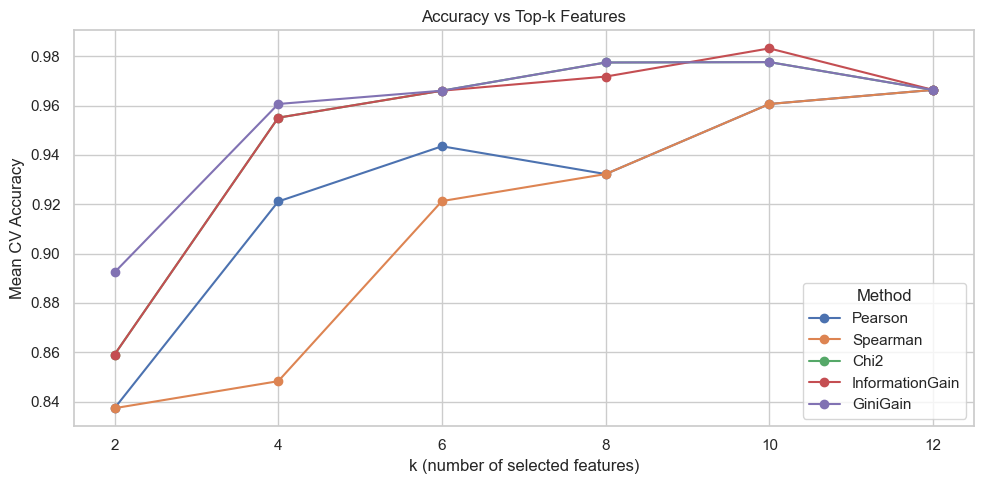

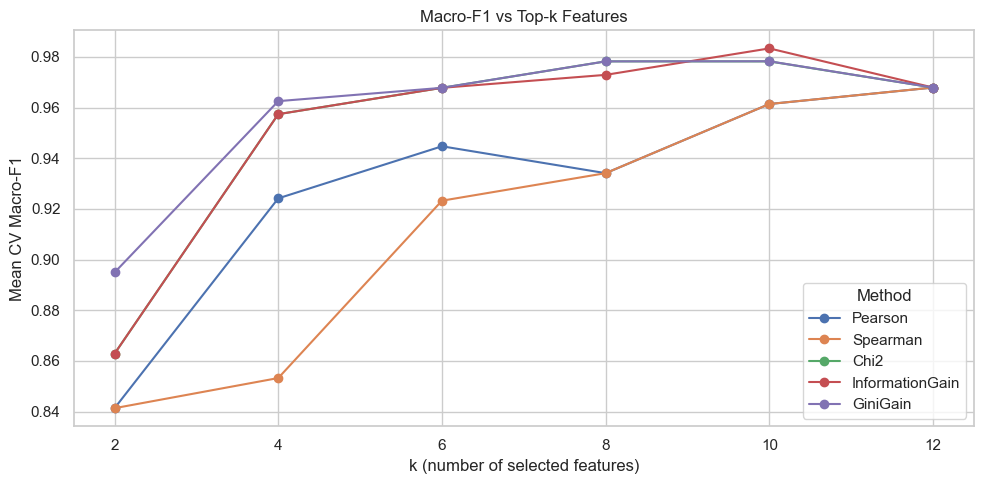

Best setting by mean accuracy:


,method,k,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
16,InformationGain,10,0.983175,0.013741,0.983351,0.01363


In [7]:
plt.figure(figsize=(10, 5))
for method in methods:
    subset = results_df[results_df['method'] == method]
    plt.plot(subset['k'], subset['accuracy_mean'], marker='o', label=method)

plt.title('Accuracy vs Top-k Features')
plt.xlabel('k (number of selected features)')
plt.ylabel('Mean CV Accuracy')
plt.legend(title='Method')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for method in methods:
    subset = results_df[results_df['method'] == method]
    plt.plot(subset['k'], subset['f1_macro_mean'], marker='o', label=method)

plt.title('Macro-F1 vs Top-k Features')
plt.xlabel('k (number of selected features)')
plt.ylabel('Mean CV Macro-F1')
plt.legend(title='Method')
plt.tight_layout()
plt.show()

best_row = results_df.sort_values('accuracy_mean', ascending=False).iloc[0]
print('Best setting by mean accuracy:')
display(best_row.to_frame().T)


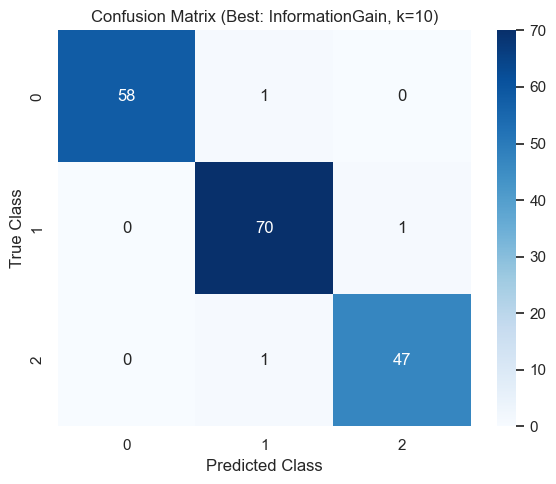

              precision    recall  f1-score   support

           0     1.0000    0.9831    0.9915        59
           1     0.9722    0.9859    0.9790        71
           2     0.9792    0.9792    0.9792        48

    accuracy                         0.9831       178
   macro avg     0.9838    0.9827    0.9832       178
weighted avg     0.9833    0.9831    0.9832       178



In [8]:
best_method = best_row['method']
best_k = int(best_row['k'])

oof_true, oof_pred = [], []
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    ranking = get_ranking(best_method, X_train, y_train, n_bins=5)
    selected = ranking.index[:best_k].tolist()

    scaler = StandardScaler()
    X_train_sel = scaler.fit_transform(X_train[selected])
    X_test_sel = scaler.transform(X_test[selected])

    lda = LDA()
    lda.fit(X_train_sel, y_train)
    preds = lda.predict(X_test_sel)

    oof_true.extend(y_test)
    oof_pred.extend(preds)

cm = confusion_matrix(oof_true, oof_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Best: {best_method}, k={best_k})')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

print(classification_report(oof_true, oof_pred, digits=4))


## 11. Theoretical Differences between Criteria

Understanding the theoretical differences between these filter metrics helps explain their diverse behaviors:

- **Pearson Correlation**: Measures the *linear* dependence between continuous variables. Since our target is categorical/multi-class, it is treated ordinally, which limits Pearson's ability to capture complex non-linear class separability.
- **Spearman Rank Correlation**: Measures *monotonic* relationships by applying Pearson to the ranked values. It is more robust to outliers and non-linear (but monotonic) shifts compared to Pearson.
- **Chi-Square Statistic**: A non-parametric test of *statistical independence* between categorical variables. Continuous features must be discretized into bins. It measures the divergence of the observed frequencies across bins and classes from the expected frequencies under the assumption of independence.
- **Information Gain (Entropy)**: Grounded in information theory, it measures the reduction in *entropy* (uncertainty) of the class labels given the feature. It captures arbitrary non-linear relationships but is sensitive to the discretization strategy.
- **Gini Gain**: Measures the reduction in *Gini Impurity*, which is the probability of misclassifying a random sample. It is theoretically similar to Information Gain but slightly more computationally efficient and often favors larger partitions.


## 12. Results Discussion

Key observations from the experiments:

- Performance generally improves with larger \(k\), then saturates.
- Correlation-based and impurity/information-based filters can produce different rankings, especially at low \(k\).
- Stability tends to increase with \(k\), since larger subsets overlap more across folds.
- Discretization-sensitive methods (Chi2/IG/Gini) may vary slightly with bin count, but broad trends remain similar.

These results illustrate the trade-off between compact feature subsets, predictive performance, and ranking robustness.


## 13. Conclusion

This notebook provides a complete, consolidated academic workflow for filter-based dimensionality reduction with Multi-Class LDA.

It includes:
- Dataset inspection and validation
- Unified EDA in the same notebook
- From-scratch feature selection metrics
- Leakage-safe CV experiments across multiple \(k\)
- Performance, stability, and sensitivity analyses

The final framework can be directly extended to other multi-class datasets and additional filter/wrapper criteria.
